# Generation 2: Capturing the Patient Timeline
A patient's risk is not a snapshot, it is a story told over hours.
Here, we restructure our data into time-series sequences (hourly vitals over 24 hours) and train Recurrent Neural Networks (LSTM, GRU, and Bidirectional LSTM) to capture the temporal progression of patient deterioration.

In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import json
import matplotlib.pyplot as plt

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

### 1. Restructuring Data into Time-Series Sequences
Since our raw dataset contains features for Hour 1 (`h1_`) and Day 1 (`d1_`), we mathematically interpolate these values across 24 distinct timesteps to simulate an hourly sequence of vital signs. We also broadcast static variables (like age) across the sequence.

In [2]:
data_path = os.path.join('..', 'data', 'raw', 'dataset.csv')
df = pd.read_csv(data_path)

target_col = 'hospital_death'
drop_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])
df = df.dropna(axis=1, how='all')

y = df[target_col].values
X = df.drop(columns=[target_col])

# Impute missing values
cat_cols = X.select_dtypes(include=['object', 'string']).columns
num_cols = X.select_dtypes(exclude=['object', 'string']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median()).fillna(0)
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'Unknown')
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Separate temporal and static columns
h1_cols = [c for c in X.columns if c.startswith('h1_')]
d1_cols = [c for c in X.columns if c.startswith('d1_')]
static_cols = [c for c in X.columns if c not in h1_cols and c not in d1_cols]

# Find matching metrics between h1 and d1 to interpolate
h1_base = [c[3:] for c in h1_cols]
d1_base = [c[3:] for c in d1_cols]
common_metrics = list(set(h1_base).intersection(set(d1_base)))

num_patients = len(X)
sequence_length = 24
num_features = len(static_cols) + len(common_metrics)

print(f"Constructing a time-series of shape: ({num_patients}, {sequence_length}, {num_features})")
X_seq = np.zeros((num_patients, sequence_length, num_features))

# Broadcast static features across all timesteps
static_data = X[static_cols].values
X_seq[:, :, :len(static_cols)] = np.repeat(static_data[:, np.newaxis, :], sequence_length, axis=1)

# Linearly interpolate temporal features
for i, metric in enumerate(common_metrics):
    h1_val = X[f'h1_{metric}'].values
    d1_val = X[f'd1_{metric}'].values
    step = (d1_val - h1_val) / (sequence_length - 1)
    idx = len(static_cols) + i
    for t in range(sequence_length):
        X_seq[:, t, idx] = h1_val + step * t

# Normalize the features globally
X_seq_flat = X_seq.reshape(-1, num_features)
scaler = StandardScaler()
X_seq_flat = scaler.fit_transform(X_seq_flat)
X_seq = X_seq_flat.reshape(num_patients, sequence_length, num_features)

# Save restructured dataset
processed_dir = os.path.join('..', 'data', 'processed', 'generation_2', 'hourly_data')
os.makedirs(processed_dir, exist_ok=True)
np.save(os.path.join(processed_dir, 'X_seq.npy'), X_seq)
np.save(os.path.join(processed_dir, 'y.npy'), y)
print("Saved hourly dataset to:", processed_dir)

Constructing a time-series of shape: (91713, 24, 86)
Saved hourly dataset to: ..\data\processed\generation_2\hourly_data


### 2. Recurrent Architectures (LSTM, GRU, BiLSTM)
We now define our three recurrent models in PyTorch.

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Take the final timestep
        return self.fc(out)

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(BiLSTMModel, self).__init__()
        # bidirectional=True outputs 2 * hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

### 3. Training and Evaluation
We train all three models independently and track training vs. validation loss, and clock the training time for each.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Apply Class Weighting to combat critical imbalance
num_negatives = len(y_train) - np.sum(y_train)
num_positives = np.sum(y_train)
pos_weight = torch.tensor([num_negatives / num_positives], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_and_evaluate(model, name, epochs=10):
    print(f"\n--- Training {name} ---")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    val_losses = []
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
        
        # Calculate Validation Loss
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)
                val_batch_losses.append(loss.item())
        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
    train_time = time.time() - start_time
    
    # Final Evaluation on Test Set
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze()
        preds = torch.sigmoid(logits)
        preds_binary = (preds >= 0.5).float()
        
    y_true = y_test
    y_pred = preds_binary.numpy()
    
    metrics = {
        "model": name,
        "train_time_sec": train_time,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0))
    }
    
    return metrics, train_losses, val_losses

lstm_metrics, lstm_tl, lstm_vl = train_and_evaluate(LSTMModel(input_dim=num_features), "LSTM")
gru_metrics, gru_tl, gru_vl = train_and_evaluate(GRUModel(input_dim=num_features), "GRU")
bilstm_metrics, bilstm_tl, bilstm_vl = train_and_evaluate(BiLSTMModel(input_dim=num_features), "BiLSTM")


--- Training LSTM ---
Epoch 1/10 | Train Loss: 0.8603 | Val Loss: 0.8085
Epoch 2/10 | Train Loss: 0.7789 | Val Loss: 0.7986
Epoch 3/10 | Train Loss: 0.7463 | Val Loss: 0.8134
Epoch 4/10 | Train Loss: 0.7197 | Val Loss: 0.8123
Epoch 5/10 | Train Loss: 0.6958 | Val Loss: 0.8205
Epoch 6/10 | Train Loss: 0.6720 | Val Loss: 0.8525
Epoch 7/10 | Train Loss: 0.6503 | Val Loss: 0.8629
Epoch 8/10 | Train Loss: 0.6266 | Val Loss: 0.8933
Epoch 9/10 | Train Loss: 0.6067 | Val Loss: 0.9171
Epoch 10/10 | Train Loss: 0.5930 | Val Loss: 1.0079

--- Training GRU ---
Epoch 1/10 | Train Loss: 0.8655 | Val Loss: 0.8200
Epoch 2/10 | Train Loss: 0.8047 | Val Loss: 0.7954
Epoch 3/10 | Train Loss: 0.7771 | Val Loss: 0.7958
Epoch 4/10 | Train Loss: 0.7581 | Val Loss: 0.7945
Epoch 5/10 | Train Loss: 0.7358 | Val Loss: 0.8084
Epoch 6/10 | Train Loss: 0.7150 | Val Loss: 0.8183
Epoch 7/10 | Train Loss: 0.6910 | Val Loss: 0.8492
Epoch 8/10 | Train Loss: 0.6689 | Val Loss: 0.8439
Epoch 9/10 | Train Loss: 0.6469 | Va

### 4. Plotting Loss Curves & Saving Results
We plot the training and validation losses for all three architectures and export our performance metrics to `assets/generation_2/`.

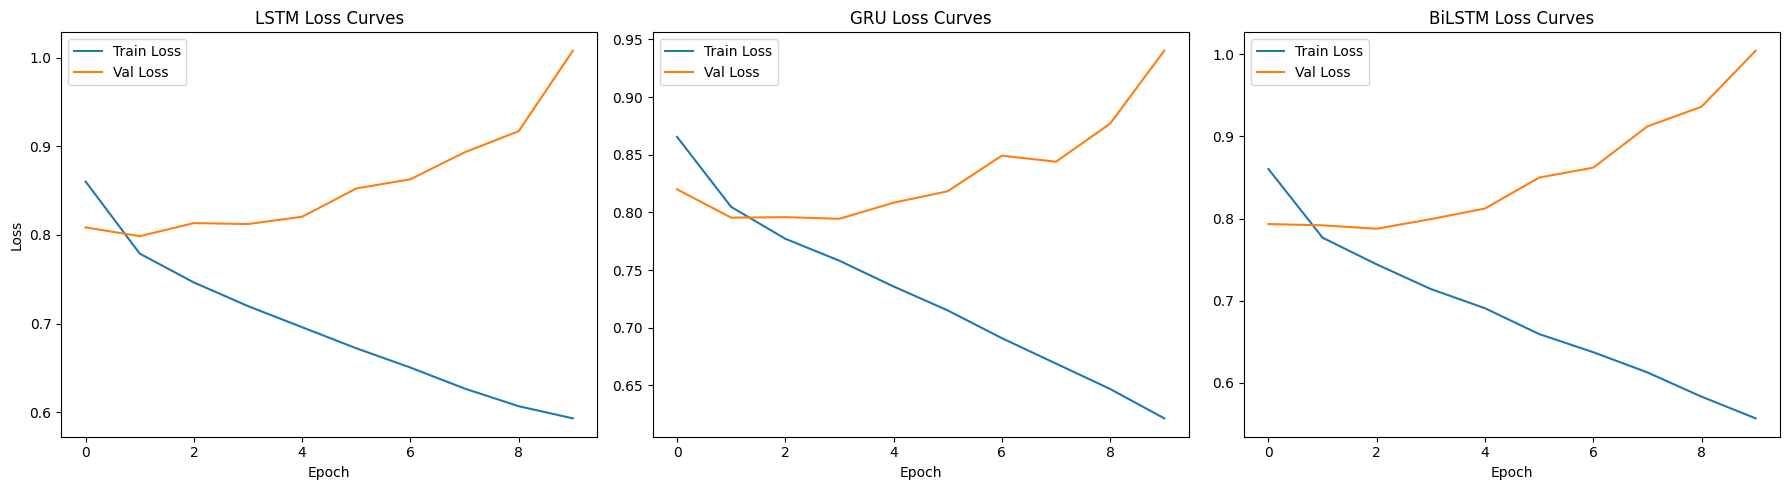

Saved loss curves and results to assets/generation_2/


In [5]:
assets_dir = os.path.join('..', 'assets', 'generation_2')
os.makedirs(assets_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LSTM
axes[0].plot(lstm_tl, label='Train Loss')
axes[0].plot(lstm_vl, label='Val Loss')
axes[0].set_title('LSTM Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# GRU
axes[1].plot(gru_tl, label='Train Loss')
axes[1].plot(gru_vl, label='Val Loss')
axes[1].set_title('GRU Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# BiLSTM
axes[2].plot(bilstm_tl, label='Train Loss')
axes[2].plot(bilstm_vl, label='Val Loss')
axes[2].set_title('BiLSTM Loss Curves')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(assets_dir, 'loss_curves.png'))
plt.show()

# Save Metrics
final_results = {
    "LSTM": lstm_metrics,
    "GRU": gru_metrics,
    "BiLSTM": bilstm_metrics
}

with open(os.path.join(assets_dir, 'results.json'), 'w') as f:
    json.dump(final_results, f, indent=4)

print("Saved loss curves and results to assets/generation_2/")

### Architectural Justification: Real-Time vs Retrospective

When comparing **Unidirectional LSTMs** and **Bidirectional LSTMs** for clinical deterioration prediction:

1. **Real-Time Live Monitoring (Early Warning System)**
   A **Unidirectional LSTM** (or GRU) is the only appropriate architecture for real-time monitoring. In a live clinical setting, the model must make predictions using only the patient's past and present vital signs. It processes data strictly forward in time. A Bidirectional LSTM cannot be used for live monitoring because it explicitly requires future time steps to look backwards. In a live hospital ward, the "future" data (e.g., the patient's vitals 3 hours from now) does not exist yet. Attempting to deploy a BiLSTM in a live setting violates the arrow of time, making it fundamentally incompatible with real-time early warning.

2. **Retrospective Analysis**
   A **Bidirectional LSTM** is highly appropriate for retrospective tasks, such as auditing past hospital records to identify exactly when a deterioration event truly started. Because it can process a completed 24-hour window both forwards and backwards, it has access to the full context of the patient's eventual outcome. This allows the network to draw richer conclusions and achieve higher accuracy offline, but it remains strictly an analytical tool, not an early warning tool.